# BiLSTM without attention: Liverpool AIS, 5–60 minutes

This separate notebook adapts the idea in `v2-bilstm-only-ship_trajectory.ipynb` to the completed NPZ release. Existing notebooks and data are read-only. Shared implementation is in `workflow.py` and `models.py` beside this notebook.

**Default: a small Cargo smoke run.** This verifies software execution, not model quality. Change `MODE` to `pilot` or `full` for a separately identified experiment. Full training has not been completed by the saved smoke results.

## Context and methods

20 grid timestamps (19-minute history), eight valid-value features plus eight mask channels, and optionally two train-standardised absolute-position channels. There are 12 future east/north targets in metres at +5, +10, …, +60 minutes. Repeated past AIS observations are permitted.

Use the supplied partitions: train before September 2025; validation September–November 2025; calibration December 2025–February 2026; exploratory test March–August 2026. No sequence regeneration, random repartitioning, future filling, or filtering out stationary records occurs here.

Neural models use shared masked training-only standardisation, a fixed 1,000-metre target scale, and either a diagonal Gaussian head or deterministic Huber loss. The Gaussian standard deviation uses softplus plus a one-metre floor with no inherited degree-based cap. The BiLSTM pair shares encoder/pooling choices so attention is the intended architecture difference. This is an adaptation, not an exact reproduction of the older implementations.

Velocity candidates use distinct actual observation timestamps and include the last observation's age. SOG/COG uses true bearings projected into UTM; invalid SOG/COG falls back to last observed positional velocity, then zero if unavailable. There is no velocity clipping.

In [1]:
from pathlib import Path
import os,sys,json
HERE=Path.cwd().resolve()
if not (HERE/'workflow.py').exists():
    HERE=HERE/'training_5_60_v1'
if not (HERE/'workflow.py').exists():
    raise RuntimeError('Open this notebook from its training_5_60_v1 folder or the project root.')
sys.path.insert(0,str(HERE))
os.environ['MPLCONFIGDIR']=str(HERE/'.cache/matplotlib')
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from workflow import config,release_info,select_plan,run_isolated,plot_run


## Configuration

`smoke`: two randomly selected shards per role, up to 64 rows per shard, one small-network epoch. `pilot`: up to 32 shards per role, 256 rows per shard, 15 epochs. `full`: all shards and all rows for each selected group, up to 100 epochs with early stopping. The same seed produces the same selected cohorts across all four notebooks.

Subset modes are engineering checks and exploratory pilots, not representative full-release evaluations. Start with Cargo/Tanker. Fishing has only two training MMSIs, and several Research_Offshore labels need review. `GROUPS` can list any saved group; the workflow records unavailable roles rather than borrowing data from another split.

In [2]:
MODE='smoke'
GROUPS=['Cargo']
ARCHITECTURE='bilstm_only'
CFG=config(MODE,GROUPS)
# Optional: CFG['probabilistic']=False  # deterministic neural positions + residual circles
# Optional: CFG['epochs']=30
# Full group list: Cargo, Tanker, Passenger, Port_Service, Research_Offshore, Fishing, Unknown
print(json.dumps(CFG,indent=2))

{
  "mode": "smoke",
  "release": "/Users/shuvo/anaconda_projects/ais_liverpool/outputs/vessel_group_forecasting/data/full_5_60_20260913T163619Z",
  "groups": [
    "Cargo"
  ],
  "seed": 42,
  "device": "cpu",
  "epochs": 1,
  "batch_size": 64,
  "learning_rate": 0.0005,
  "width": 16,
  "dropout": 0.2,
  "patience": 12,
  "max_shards": 2,
  "rows_per_shard": 64,
  "coverage": 0.9,
  "target_scale_m": 1000.0,
  "sigma_floor_m": 1.0,
  "use_spatial_context": true,
  "probabilistic": true,
  "verify_checksums": true
}


## Data and selected cohorts

In [3]:
release,index,manifest=release_info(CFG)
rows=[]
for group in CFG['groups']:
    for role in ['train','validation','calibration','test']:
        plan=select_plan(index,group,role,CFG)
        rows.append({'group':group,'role':role,'shards':len(plan),'selected_windows':sum(p['n'] for p in plan)})
display(pd.DataFrame(rows))
print('Dataset:',release)
print('All source shards are opened read-only; no MySQL access is used.')

,group,role,shards,selected_windows
0,Cargo,train,2,128
1,Cargo,validation,2,128
2,Cargo,calibration,2,128
3,Cargo,test,2,90


Dataset: /Users/shuvo/anaconda_projects/ais_liverpool/outputs/vessel_group_forecasting/data/full_5_60_20260913T163619Z
All source shards are opened read-only; no MySQL access is used.


## Run the training and evaluation flow

Training runs in a separate local Python process using the same environment, with progress streamed here. This keeps TensorFlow native execution separate from the notebook kernel; settings and logs are saved under `jobs/`.

1. Save configuration, source fingerprints and exact selected shard/row cohorts.
2. Fit the feature scaler on training examples only, then train the neural model and select its checkpoint by validation loss. For baselines, compare the seven fixed candidates on validation ADE and record the selected candidate.
3. Freeze model weights and estimate a separate per-horizon radial residual quantile from calibration examples.
4. Evaluate the frozen model/regions on the selected test cohort, saving errors, empirical coverage, area and vessel/month breakdowns. Every baseline candidate is reported; the validation-selected one is explicitly flagged.

The resulting ellipses (circles for deterministic models/baselines) target 90% per-horizon **2D** coverage. They are empirically adjusted regions, not a guarantee of whole-trajectory coverage. Overlapping windows and temporal shift invalidate a simple IID guarantee; inspect coverage by month/group and reserve independent future confirmation. Gaussian spread does not measure all model uncertainty.

In [4]:
RUN=run_isolated(ARCHITECTURE,CFG)
print('Saved experiment:',RUN)

Cargo: train=128, validation=128, calibration=128, test=90


2/2 - 2s - 1s/step - loss: 24.9422 - val_loss: 39.6504 - learning_rate: 5.0000e-04


Cargo complete.


Saved experiment: /Users/shuvo/anaconda_projects/ais_liverpool/training_5_60_v1/runs/smoke_bilstm_only_20260914T040057_112596Z


## Results from this run

In [5]:
results=pd.read_csv(RUN/'comparison.csv')
display(results)
print('These are',CFG['mode'].upper(),'results. Do not describe smoke metrics as trained-model research findings.')
print('Empty roles:',json.loads((RUN/'skipped_groups.json').read_text()))

,group,model,selected_baseline,role,windows,ade_m,fde_60_m,plan_hash,mode,mean_horizon_coverage
0,Cargo,bilstm_only,False,test,90,8547.926503,13725.080495,8820a3de6592fa6650fd7926f8617202852decdfb05812...,smoke,0.753704


These are SMOKE results. Do not describe smoke metrics as trained-model research findings.
Empty roles: []


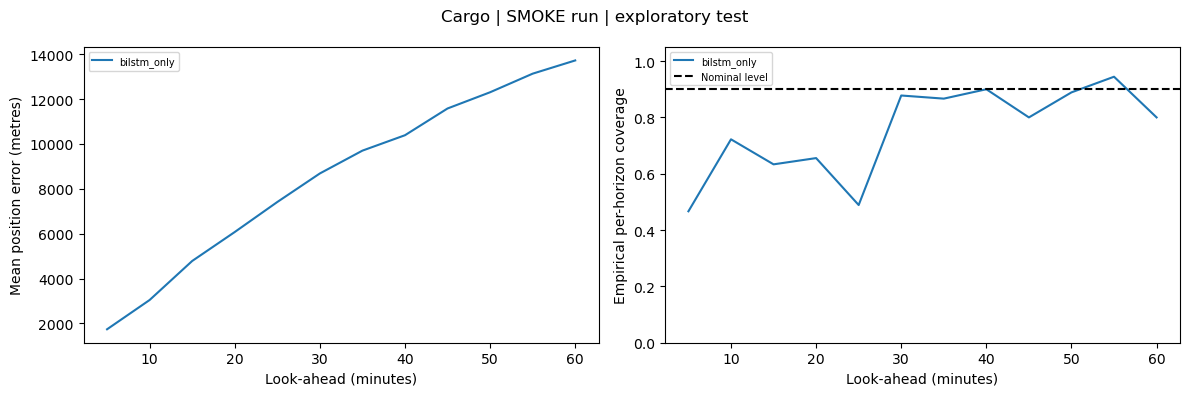

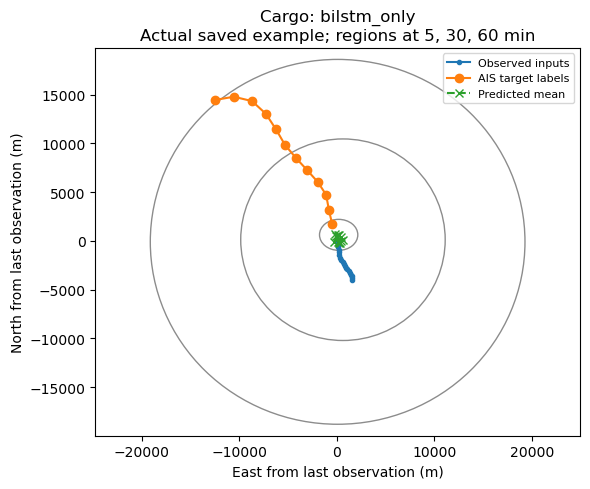

In [6]:
figures=plot_run(RUN)
plt.show()

## Takeaways and next steps

The tables and plots above come from this run. Full-release conclusions require completed full runs under a frozen protocol. Compare notebooks only using identical source fingerprints, roles and selected cohorts; `compare_runs` rejects mismatched cohort plans. Report each horizon and vessel/month support, rather than selecting models using test performance.

Known dataset limits remain: approximately 98.64% interpolated targets; 84.94% of test windows in March and just one in August; heavy vessel concentration; static group mapping and future-informed offline cleaning. These cannot be repaired by choosing a different neural architecture.

All writes are in this new folder. Runs are versioned and are not overwritten. A failed run is marked failed; model checkpoints are preserved for inspection. Automatic training resumption is not implemented. For shared versus specialist research controls, use a separately specified follow-up experiment; the four notebooks here compare the requested model families within each vessel group.